# Package loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

/Users/leishi/opt/anaconda3/envs/dkrl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import pandas as pd
import numpy as np

# Define the path to your CSV file
file_path = 'upworthy-archive-datasets/upworthy-archive-exploratory-packages-03.12.2020.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
# print(df.head())

# pull the headlines
unique_headlines = df['headline'].drop_duplicates().reset_index(drop=True)
print(unique_headlines)

unique_headlines.to_csv('unique_headlines.csv', index=False, header=True)

0        They're Being Called 'Walmart's Worst Nightmar...
1              This Is What Sexism Against Men Sounds Like
2        Kim Jong Un Would Really Hate For You To Watch...
3        What They Learned From The Scientist Was Terri...
4        A Bunch Of Celebrities Recorded A Song To Rais...
                               ...                        
12382    A Pen, Paper, And Watercolors Tell One Of The ...
12383      Newsflash: Black People Travel Too. Here's Why.
12384    5 Reasons You May Need To Plan A Vacation - Ri...
12385    The Next Time You Encounter A Small Minded Big...
12386    I've Never Wanted To Buy A Plane Ticket More T...
Name: headline, Length: 12387, dtype: object


In [ ]:
# generate embeddings for the headlines
from sentence_transformers import SentenceTransformer

# Load the SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L12-v2')

# Define a function to compute embeddings
def compute_embeddings(questions):
    return model.encode(questions, convert_to_tensor=True).cpu().numpy()

In [6]:
# Compute embeddings for unique headlines
len(compute_embeddings("unique_headlines"))

384

In [9]:
# Compute embeddings for all unique headlines
embeddings = compute_embeddings(unique_headlines.tolist())

# Save to a CSV file 
np.savetxt('embeddings.csv', embeddings, delimiter=',')

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'

# Compute the correlation matrix

In [3]:
embeddings = np.loadtxt('embeddings.csv', delimiter=',')

# Compute the correlation matrix
correlation_matrix = np.corrcoef(embeddings)

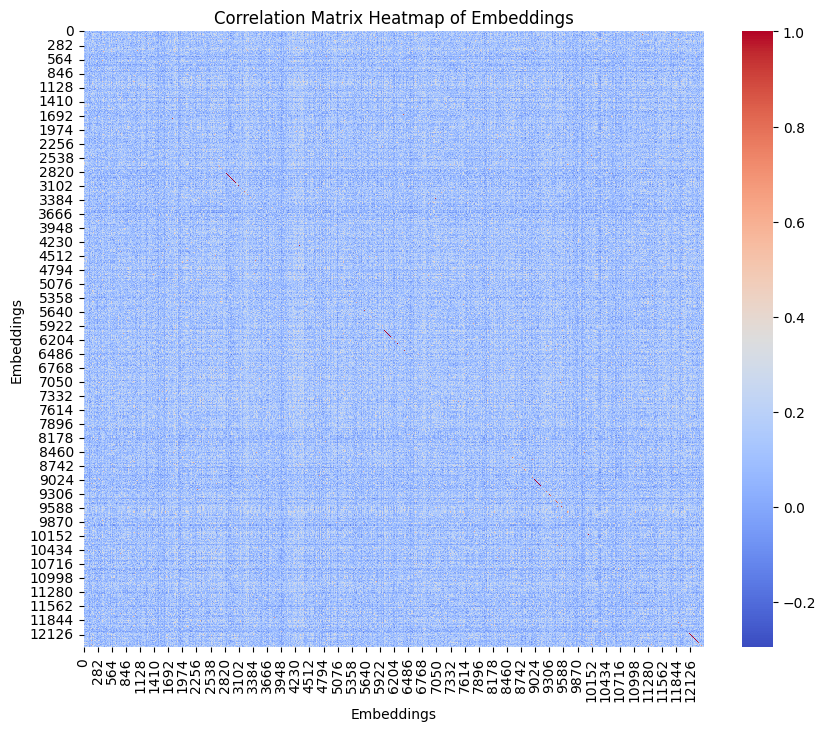

In [8]:
# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix Heatmap of Embeddings')
plt.xlabel('Embeddings')
plt.ylabel('Embeddings')
plt.show()